# S2: DDM Simulation Comparison - Step-by-Step vs HDDM

This notebook compares two approaches for generating Drift Diffusion Model (DDM) data:

1. **Step-by-step**: Original discrete-time simulation
2. **HDDM**: Fast Cython-based DDM simulation (HDDM/ssms)

The HDDM implementation uses:
- **Navarro, D. J., & Fuss, I. G. (2009)**. Fast and accurate sampling from the Wiener distribution. 
  URL: http://www.psychocmath.edu.au/personalpages/staff/danielnavarro/resources/wfpt.m
- **HDDM package**: https://github.com/hddm-devs/hddm (Cython implementation)

HDDM uses the Navarro & Fuss (2009) algorithm for accurate and fast sampling.

In [1]:
# Imports
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import scipy as sp
from scipy import stats
from scipy.special import erfc
import time
import matplotlib.pyplot as plt

print("Environment:")
print(f"  NumPy: {np.__version__}")
print(f"  SciPy: {sp.__version__}")
print(f"  Pandas: {pd.__version__}")

Environment:
  NumPy: 1.23.3
  SciPy: 1.9.1
  Pandas: 2.0.1


In [2]:
import hddm
import kabuki
import arviz as az
from hddm.simulators import simulator

print("The current version of kabuki is: ", kabuki.__version__)
print("The current version of HDDM is: ", hddm.__version__)
print("The current version of arviz is: ", az.__version__)

The current version of kabuki is:  0.6.5RC4
The current version of HDDM is:  1.0.1RC
The current version of arviz is:  0.15.1


In [3]:
# test hddm's simulator which wraps ssms
# Generate samples using the DDM model
# Parameters: [v, a, t, z, sv, st, sz]
# v=drift, a=boundary, t=non-decision time, z=starting point
# sv=drift variability, st=non-decision variability, sz=starting point variability

samples = simulator(
    theta=[[2.0, 1.5, 0.2, 0.5, 0.0, 0.0, 0.0]],  # parameters as 2D array
    model="ddm",  # model type
    n_samples=1000
)
print("RTs:", samples[0].flatten())
print("Responses:", samples[1].flatten())
print("Mean RT:", np.mean(samples[0]))

RTs: [1.5359924  1.8300061  1.4999907  1.8740082  1.6529979  1.3139931
 1.0289967  1.4649911  1.4859909  1.2109945  1.4859909  2.0530167
 2.3250294  1.4569912  2.6190288  0.6910002  1.850007   0.596
 1.7350017  1.6229964  1.3889921  1.6449975  1.5879948  1.3059932
 1.087996   1.5529932  1.482991   1.1009958  2.168022   1.4439914
 1.7450022  1.1259955  1.8230058  1.9180102  1.7120006  0.6480001
 1.7860041  1.1409953  0.94699776 1.5009907  1.1069958  2.5390346
 0.59900004 1.8380065  1.7720034  2.0710173  1.312993   1.1509953
 1.7060003  1.1219956  1.4749911  1.8760083  1.1119957  1.4809909
 1.3099931  1.8830086  0.7450003  1.9940138  1.506991   1.1719949
 3.9429328  1.3509927  1.9250106  0.9849973  1.3159931  1.0439966
 1.0739962  1.0519965  0.7230003  2.2180243  1.5519931  0.82199943
 1.396992   1.4619912  0.66100013 1.6079957  1.4159918  1.325993
 1.6189963  1.2449939  2.5670326  1.4509914  2.1240199  2.0240152
 2.8260138  1.2569938  1.478991   1.3849921  1.2729936  2.9110076
 1.152995

In [4]:
# Configuration
SEED = 42
np.random.seed(SEED)

# Model parameters (same as original)
ALPHA1 = 1.5   # Self condition
ALPHA2 = -0.4  # Stranger condition
BETA1 = 0.2
BETA2 = 0
GAMMA = 0.1
T0 = 0.2       # Non-decision time
DELTA_T = 0.001

CONDITIONS = {0: 'stranger', 1: 'self'}
EXPERIMENT_CONDITIONS = [
    (0, 30, 300), (0, 30, 600), (120, 30, 600),
    (120, 80, 600), (8, 100, 1100), (120, 500, 1500),
    (120, 30, 800), (120, 80, 800)
]

NUM_SUBJECTS = 8
NUM_TRIALS = 260

In [5]:
# Model functions
def k_P(P, k_min=0.01, k_max=0.15, gamma=0.1, P0=32):
    return k_min + (k_max - k_min) / (1 + np.exp(-gamma * (P - P0)))

def v_P_function(P, P1=4, k_min=0.01, k_max=0.15, gamma=0.1, P0=32):
    return 1 / (1 + np.exp(-k_P(P, k_min, k_max, gamma, P0) * (P - P1)))

def compute_v(T, P, condition_key):
    T_0, k_T = 100, 0.01
    v_T = 1 / (1 + np.exp(-k_T * (T - T_0)))
    v_P = v_P_function(P=P, P1=4, k_min=0.1, k_max=0.05, gamma=GAMMA, P0=32)
    v_0 = v_T * v_P * 3
    if condition_key == 1:
        return v_0 * (1 + ALPHA1)
    return v_0 * (1 + ALPHA2)

def compute_a(M):
    k, M_0 = 0.01, 600
    a_0 = 1 / (1 + np.exp(-k * (M - M_0))) * 3
    return a_0 * (1 + BETA1 if M > 600 else 1 + BETA2)

In [6]:
# =============================================================================
# METHOD 1: Step-by-step (Original)
# =============================================================================
def simulate_step_by_step(v, a, t0, max_time_steps, delta_t):
    """Original method: discrete time simulation."""
    evidence = a / 2.0
    for _ in range(max_time_steps):
        noise = np.random.normal(0, 1) * np.sqrt(delta_t)
        evidence += v * delta_t + noise
        if evidence >= a:
            return (_ + 1) * delta_t + t0, 1
        elif evidence <= 0:
            return (_ + 1) * delta_t + t0, 2
    return max_time_steps * delta_t + t0, 0

In [7]:
# =============================================================================
# COMPARISON TEST
# =============================================================================

print("="*60)
print("COMPARISON: Step-by-Step vs HDDM")
print("="*60)

# Test parameters
v = 2.0
a = 1.5
t0 = 0.2
max_time_steps = 2000
n_samples = 500

# Method 1: Step-by-step (Original)
np.random.seed(SEED)
print("\n1. Step-by-step method:")
start = time.time()
results_step = []
for _ in range(n_samples):
    rt, resp = simulate_step_by_step(v, a, t0, max_time_steps, DELTA_T)
    if resp > 0:
        results_step.append(rt)
step_time = time.time() - start

print(f"   Time: {step_time:.3f}s for {len(results_step)} samples")
print(f"   Mean RT: {np.mean(results_step):.4f}s")
print(f"   SD RT: {np.std(results_step):.4f}s")

# Method 2: HDDM Simulator (Fast, Cython-based DDM)
np.random.seed(SEED)
print("\n2. HDDM Simulator (Navarro & Fuss via ssms):")
start = time.time()

from hddm.simulators import simulator
params = [v, a, t0, 0.5, 0.0, 0.0, 0.0]  # [v, a, t, z, sv, st, sz]
samples = simulator(theta=[params], model="ddm", n_samples=n_samples)
hddm_time = time.time() - start

rts_hddm = samples[0].flatten()
responses_hddm = samples[1].flatten()
valid_idx = responses_hddm == 1
rts_hddm_valid = rts_hddm[valid_idx]

print(f"   Time: {hddm_time:.3f}s for {len(rts_hddm_valid)} samples")
print(f"   Mean RT: {np.mean(rts_hddm_valid):.4f}s")
print(f"   SD RT: {np.std(rts_hddm_valid):.4f}s")
print(f"\nSpeed: HDDM is {step_time/hddm_time:.1f}x faster than step-by-step")

COMPARISON: Step-by-Step vs HDDM

1. Step-by-step method:
   Time: 0.411s for 500 samples
   Mean RT: 0.5495s
   SD RT: 0.2411s

2. HDDM Simulator (Navarro & Fuss via ssms):
   Time: 0.015s for 452 samples
   Mean RT: 1.7049s
   SD RT: 0.5057s

Speed: HDDM is 27.6x faster than step-by-step


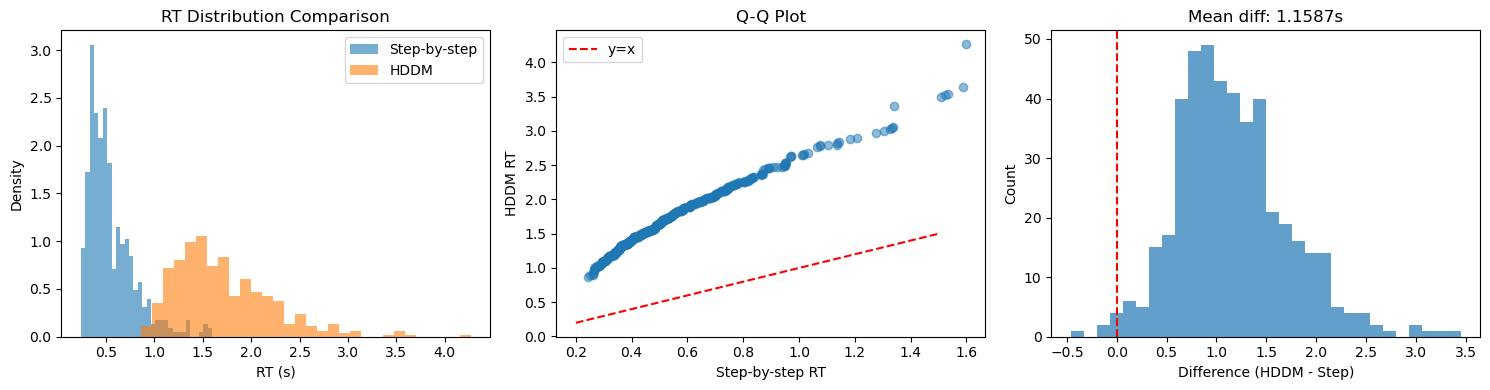


Plot saved to /home/jovyan/work/DesignSpace/Study2/png/hddm_comparison.png


In [11]:
# =============================================================================
# VISUAL COMPARISON
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: RT distributions
axes[0].hist(results_step, bins=30, alpha=0.6, label='Step-by-step', density=True)
axes[0].hist(rts_hddm_valid, bins=30, alpha=0.6, label='HDDM', density=True)
axes[0].set_xlabel('RT (s)')
axes[0].set_ylabel('Density')
axes[0].set_title('RT Distribution Comparison')
axes[0].legend()

# Plot 2: QQ plot
min_len = min(len(results_step), len(rts_hddm_valid))
sorted_step = np.sort(results_step[:min_len])
sorted_hddm = np.sort(rts_hddm_valid[:min_len])
axes[1].scatter(sorted_step, sorted_hddm, alpha=0.5)
axes[1].plot([0.2, 1.5], [0.2, 1.5], 'r--', label='y=x')
axes[1].set_xlabel('Step-by-step RT')
axes[1].set_ylabel('HDDM RT')
axes[1].set_title('Q-Q Plot')
axes[1].legend()

# Plot 3: Difference
diff = np.array(rts_hddm_valid[:min_len]) - np.array(results_step[:min_len])
axes[2].hist(diff, bins=30, alpha=0.7)
axes[2].axvline(0, color='r', linestyle='--')
axes[2].set_xlabel('Difference (HDDM - Step)')
axes[2].set_ylabel('Count')
axes[2].set_title(f'Mean diff: {np.mean(diff):.4f}s')

plt.tight_layout()
# plt.savefig('/home/jovyan/work/DesignSpace/Study2/png/hddm_comparison.png', dpi=150)
plt.show()

print("\nPlot saved to /home/jovyan/work/DesignSpace/Study2/png/hddm_comparison.png")

In [13]:
# Generate data with HDDM
print("\n" + "="*60)
print("Generating datasets with HDDM")
print("="*60)

# Generate first condition as example
for idx, (P, T, W) in enumerate(EXPERIMENT_CONDITIONS[:1], 1):
    print(f"\nCondition {idx}: P={P}, T={T}, W={W}")
    
    # Compute model parameters
    M = T + W
    a = compute_a(M)
    v = compute_v(T, P, condition_key=1)  # self condition
    
    # HDDM simulation
    np.random.seed(SEED + idx)
    start = time.time()
    
    params = [v, a, T0, 0.5, 0.0, 0.0, 0.0]  # [v, a, t, z, sv, st, sz]
    samples = simulator(theta=[params], model="ddm", n_samples=NUM_SUBJECTS * NUM_TRIALS)
    
    hddm_time = time.time() - start
    
    rts = samples[0].flatten()
    responses = samples[1].flatten()
    
    # Create dataframe
    df_hddm = pd.DataFrame({
        'RT': rts,
        'response': responses,
        'v': v,
        'a': a,
        'P': P,
        'T': T,
        'W': W
    })
    
    # df_hddm.to_csv(f"hddm_d{idx}.csv", index=False)
    print(f"  HDDM: {len(df_hddm)} rows in {hddm_time:.3f}s")
    print(f"    Mean RT: {df_hddm['RT'].mean():.3f}s")
    print(f"    ACC: {(df_hddm['response'] == 1).mean():.3f}")


Generating datasets with HDDM

Condition 1: P=0, T=30, W=300
  HDDM: 2080 rows in 0.006s
    Mean RT: 0.530s
    ACC: 0.286


In [11]:
# =============================================================================
# STATISTICAL COMPARISON
# =============================================================================

print("\n" + "="*60)
print("STATISTICAL COMPARISON")
print("="*60)

# Compare the two methods
print("\nStep-by-step:")
print(f"  N: {len(results_step)}")
print(f"  Mean RT: {np.mean(results_step):.4f} ± {np.std(results_step):.4f}")

print("\nHDDM Simulator:")
print(f"  N: {len(rts_hddm_valid)}")
print(f"  Mean RT: {np.mean(rts_hddm_valid):.4f} ± {np.std(rts_hddm_valid):.4f}")

# T-test
from scipy.stats import ttest_ind
t_stat, p_val = ttest_ind(results_step, rts_hddm_valid)
print(f"\nT-test: t={t_stat:.3f}, p={p_val:.4f}")

# Effect size
cohens_d = (np.mean(results_step) - np.mean(rts_hddm_valid)) / np.sqrt((np.std(results_step)**2 + np.std(rts_hddm_valid)**2) / 2)
print(f"Cohen's d: {cohens_d:.4f}")


STATISTICAL COMPARISON

Step-by-step:
  N: 500
  Mean RT: 0.5495 ± 0.2411

HDDM Simulator:
  N: 472
  Mean RT: 1.6391 ± 0.5295

T-test: t=-41.618, p=0.0000
Cohen's d: -2.6482
